# Tests sur les MLP

### Pytorch tests

In [2]:
import torch
print(torch.cuda.is_available())

True


## Classic SDFS

In [56]:
import matplotlib.pyplot as plt
import numpy as np

def square(x, y, r):

    dx = np.abs(x) - r
    dy = np.abs(y) - r 
    

    external_dist = np.sqrt(np.maximum(dx, 0.0)**2 + np.maximum(dy, 0.0)**2)
    
    internal_dist = np.minimum(np.maximum(dx, dy), 0.0)
    
    return external_dist + internal_dist

def circle(x, y, r):
    return np.sqrt(x**2 + y**2) - r


def sdRhombus(x, y, size):
    px = np.abs(x)
    py = np.abs(y)

    if isinstance(size, (int, float)):
        size = np.array([size, size])

    wb = size[0]
    hb = size[1]

    h = np.clip(( (wb - 2.0 * px) * wb - (hb - 2.0 * py) * hb ) / (wb*wb + hb*hb), -1.0, 1.0)
    

    dx = px - 0.5 * wb * (1.0 - h)
    dy = py - 0.5 * hb * (1.0 + h)
    

    d = np.sqrt(dx**2 + dy**2) * np.sign(dx + dy)
    
    return d


def sdHexagon(x, y, r):
    # Constants from the GLSL version
    kx, ky, kz = -0.866025404, 0.5, 0.577350269
    
    px = np.abs(x)
    py = np.abs(y)
    

    dot_kp = kx * px + ky * py
    sc = 2.0 * np.minimum(dot_kp, 0.0)
    px -= sc * kx
    py -= sc * ky
    
  
    px -= np.clip(px, -kz * r, kz * r)
    py -= r
    
    return np.sqrt(px**2 + py**2) * np.sign(py)

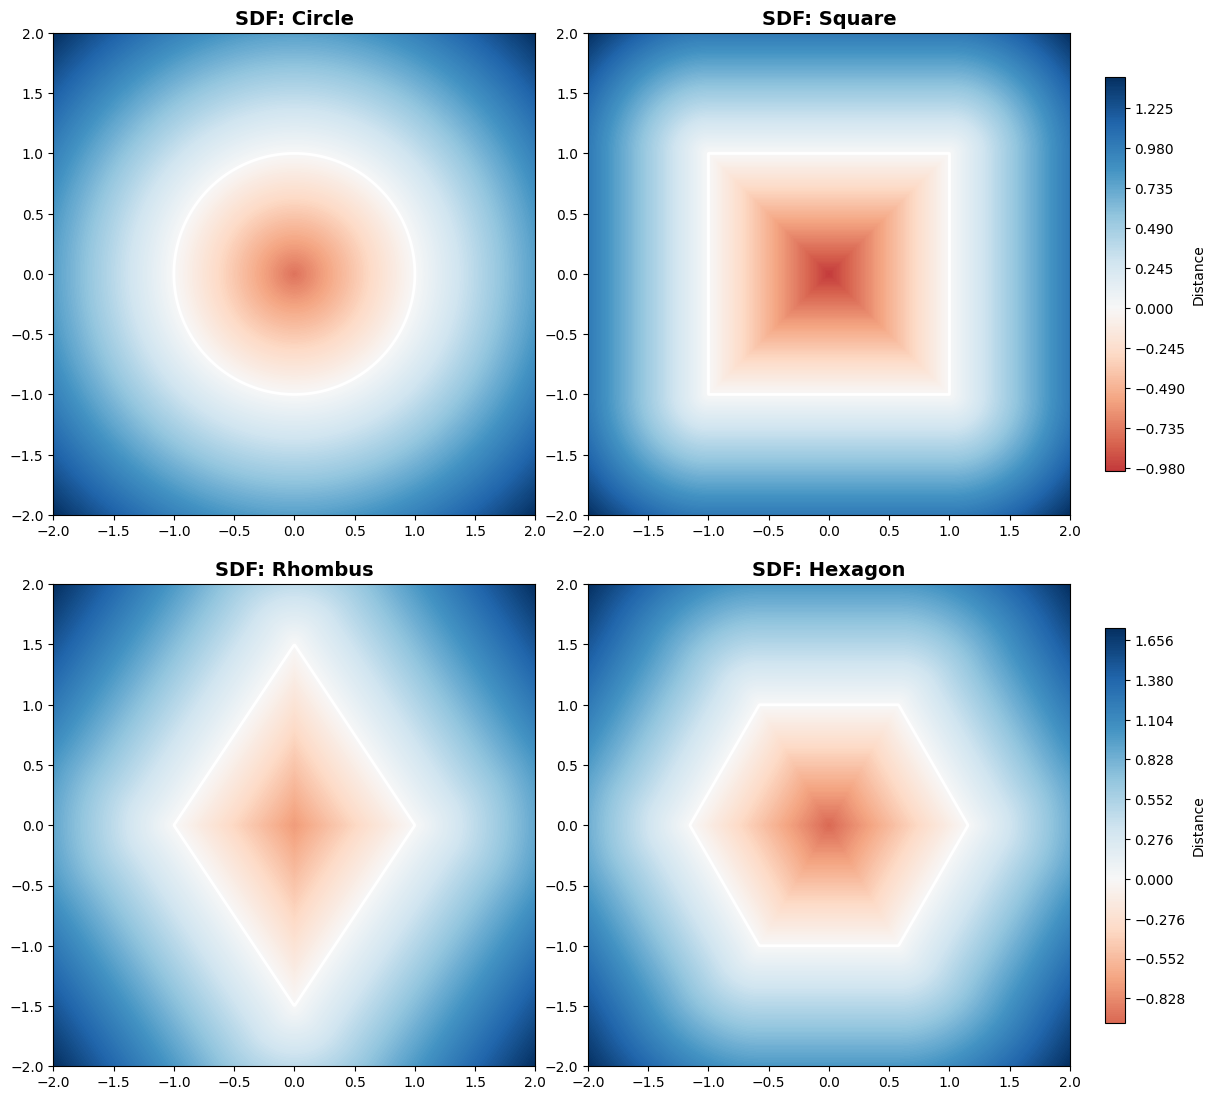

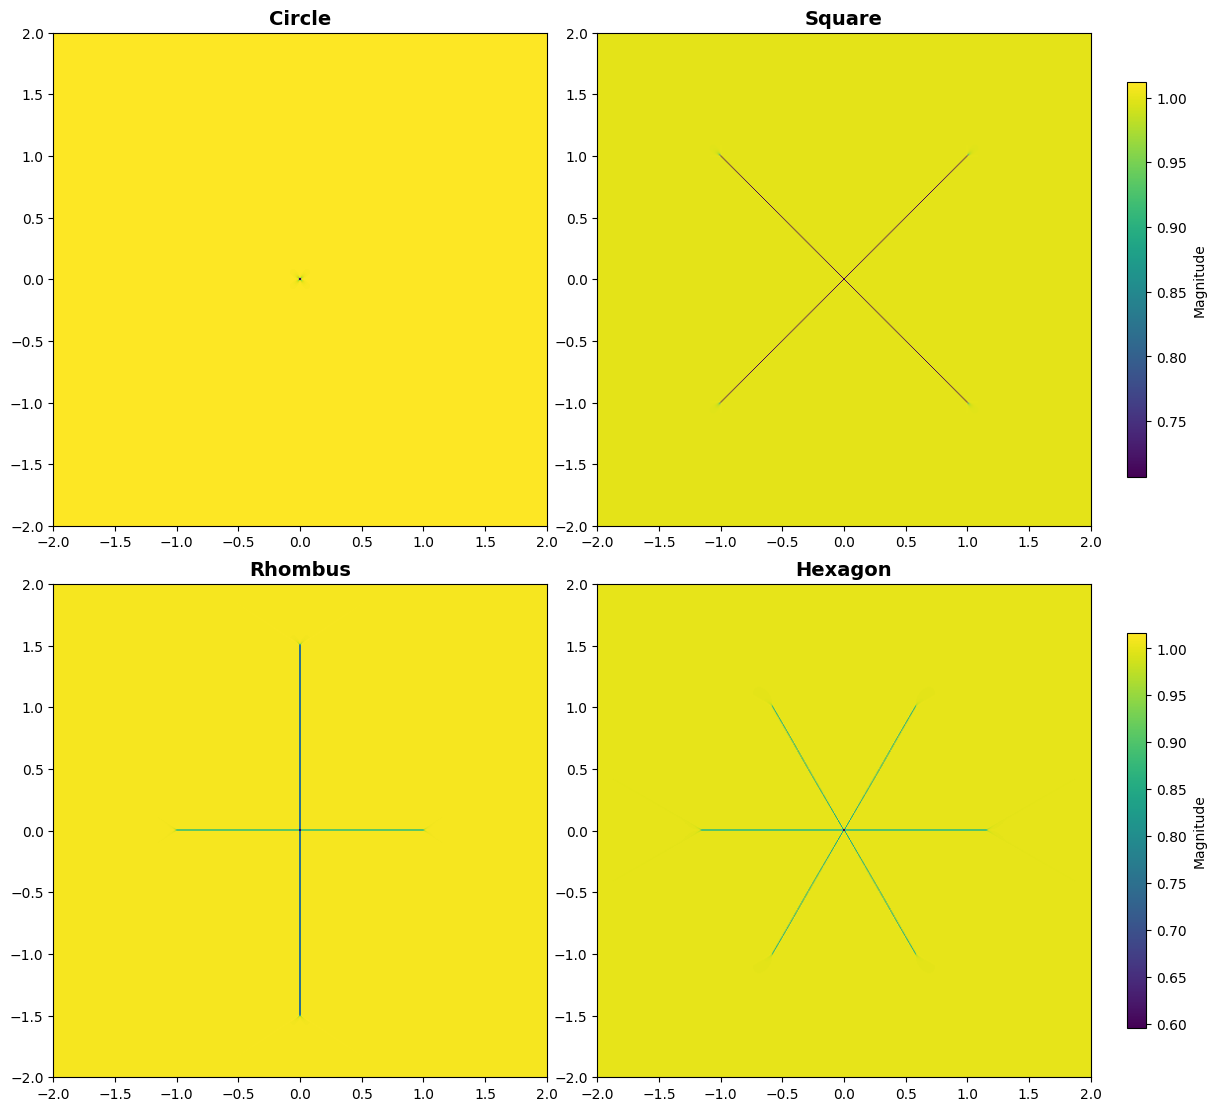

In [89]:
# --- Grid Setup ---
grid_res = 500
extent = [-2, 2, -2, 2]
gridx = np.linspace(extent[0], extent[1], grid_res)
gridy = np.linspace(extent[2], extent[3], grid_res)
X, Y = np.meshgrid(gridx, gridy)
spacing = gridx[1] - gridx[0]

# Generate Data
shapes = [
    ("Circle", circle(X, Y, 1.0)),
    ("Square", square(X, Y, 1.0)),
    ("Rhombus", sdRhombus(X, Y, [1.0, 1.5])),
    ("Hexagon", sdHexagon(X, Y, 1.0))
]

# --- Plotting ---
fig, axes = plt.subplots(2, 2, figsize=(12, 11), constrained_layout=True)
axes = axes.flatten()

for i, (name, Z) in enumerate(shapes):
    ax = axes[i]
    
    # Contour Plot
    #Center the colormap around zero for better visualization of inside/outside
    max_abs = np.max(np.abs(Z))
    cp = ax.contourf(X, Y, Z, levels=500, cmap='RdBu', vmin=-max_abs, vmax=max_abs)
    ax.contour(X, Y, Z, levels=[0], colors='white', linewidths=2)
    
    # Formatting
    ax.set_title(f"SDF: {name}", fontsize=14, fontweight='bold')
    ax.set_aspect('equal')
    ax.set_xlim(extent[0], extent[1])
    ax.set_ylim(extent[2], extent[3])
    
    if i % 2 == 1: # Only add colorbar to the right side to keep it tight
        fig.colorbar(cp, ax=ax, label='Distance', shrink=0.8)

plt.show()

# --- Gradient Magnitude Comparison ---
fig, axes = plt.subplots(2, 2, figsize=(12, 11), constrained_layout=True)
axes = axes.flatten()

for i, (name, Z) in enumerate(shapes):
    ax = axes[i]
    
    gy, gx = np.gradient(Z, spacing)
    magnitude = np.sqrt(gx**2 + gy**2)
    
    im = ax.imshow(magnitude, extent=extent, origin='lower', cmap='viridis')
    ax.set_title(f"{name}", fontsize=14, fontweight='bold')
    ax.set_aspect('equal')
    
    if i % 2 == 1:
        fig.colorbar(im, ax=ax, label='Magnitude', shrink=0.8)

plt.show()

## Basic MLP

In [62]:
import torch.nn as nn

class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(2, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, 1)
        )

    def forward(self,x):
        return self.layers(x)

In [59]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def train_sdf(model, sdf_func, nb_samples, lr, nb_epochs, loss_type='mse'):
    #between -2 and 2
    x = (torch.randn(nb_samples,2)*4) - 2
    y = sdf_func(x[:,0], x[:,1], 1)

    model = model.to(device)
    criterion = nn.MSELoss() if loss_type == 'mse' else nn.L1Loss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    x = x.to(device)
    y = y.to(device)

    for epoch in range(nb_epochs):
        optimizer.zero_grad()
        output = model(x).squeeze()
        loss = criterion(output, y)
        loss.backward()
        optimizer.step()
        if epoch % 100 == 0:
            print(f"Epoch {epoch}, Loss: {loss.item()}")
    return model

In [61]:
mlp_circle = train_sdf(MLP(), circle, 1000, 0.001, 2000, 'mse')
mlp_square = train_sdf(MLP(), square, 1000, 0.001, 2000, 'mse')
mlp_hexagon = train_sdf(MLP(), sdHexagon, 1000, 0.001, 2000, 'mse')
mlp_rhombus = train_sdf(MLP(), sdRhombus, 1000, 0.001, 2000, 'mse')

/tmp/ipykernel_564065/3912917262.py:17: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  return np.sqrt(x**2 + y**2) - r


Epoch 0, Loss: 30.20370864868164
Epoch 100, Loss: 21.9633846282959
Epoch 200, Loss: 21.9633846282959
Epoch 300, Loss: 21.9633846282959
Epoch 400, Loss: 21.9633846282959
Epoch 500, Loss: 21.9633846282959


KeyboardInterrupt: 

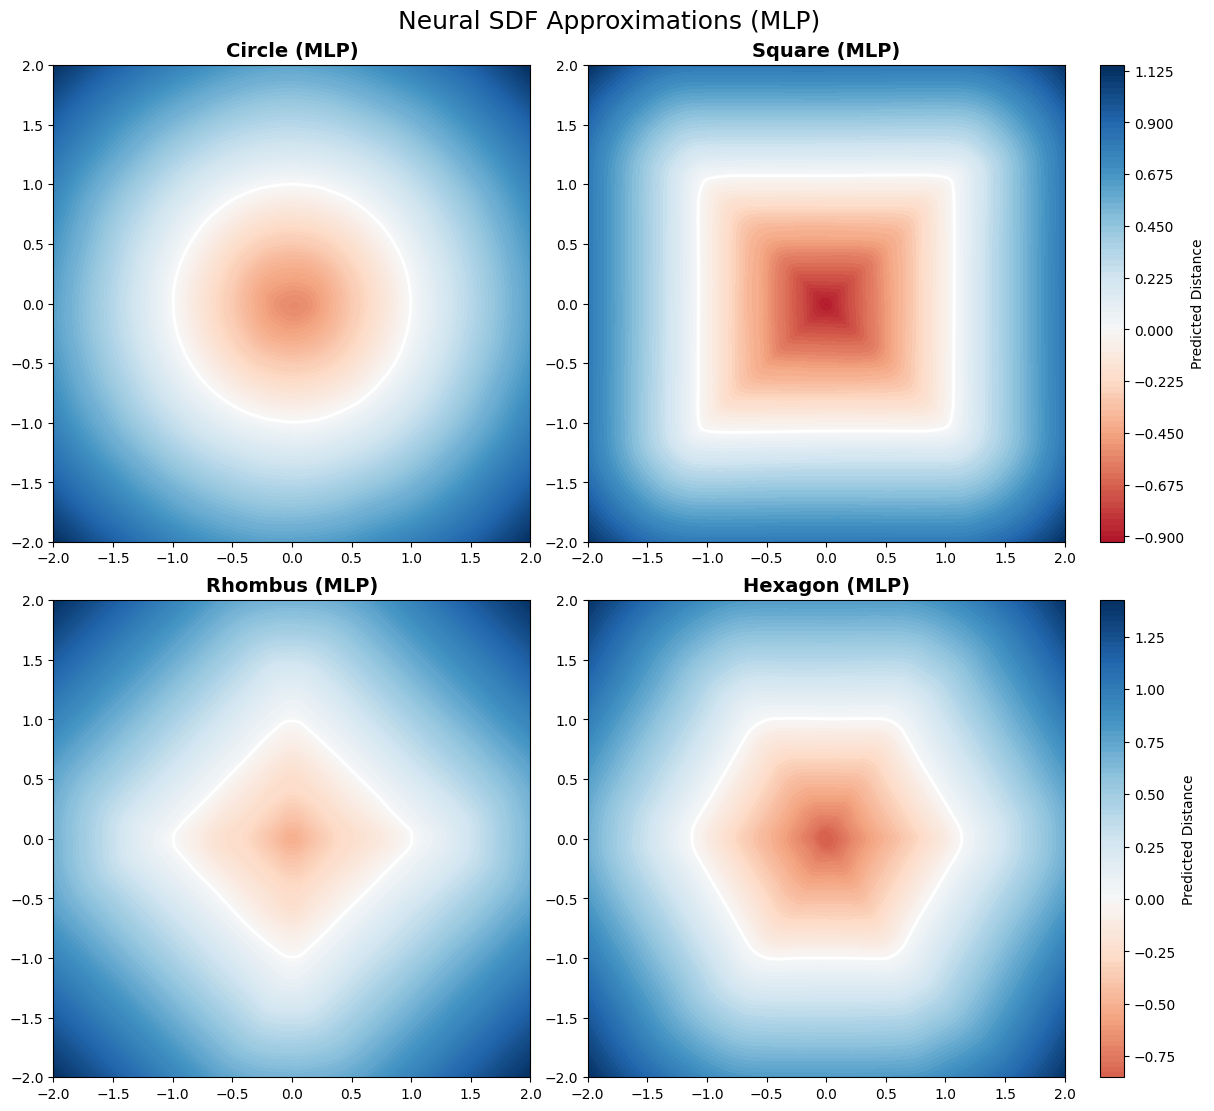

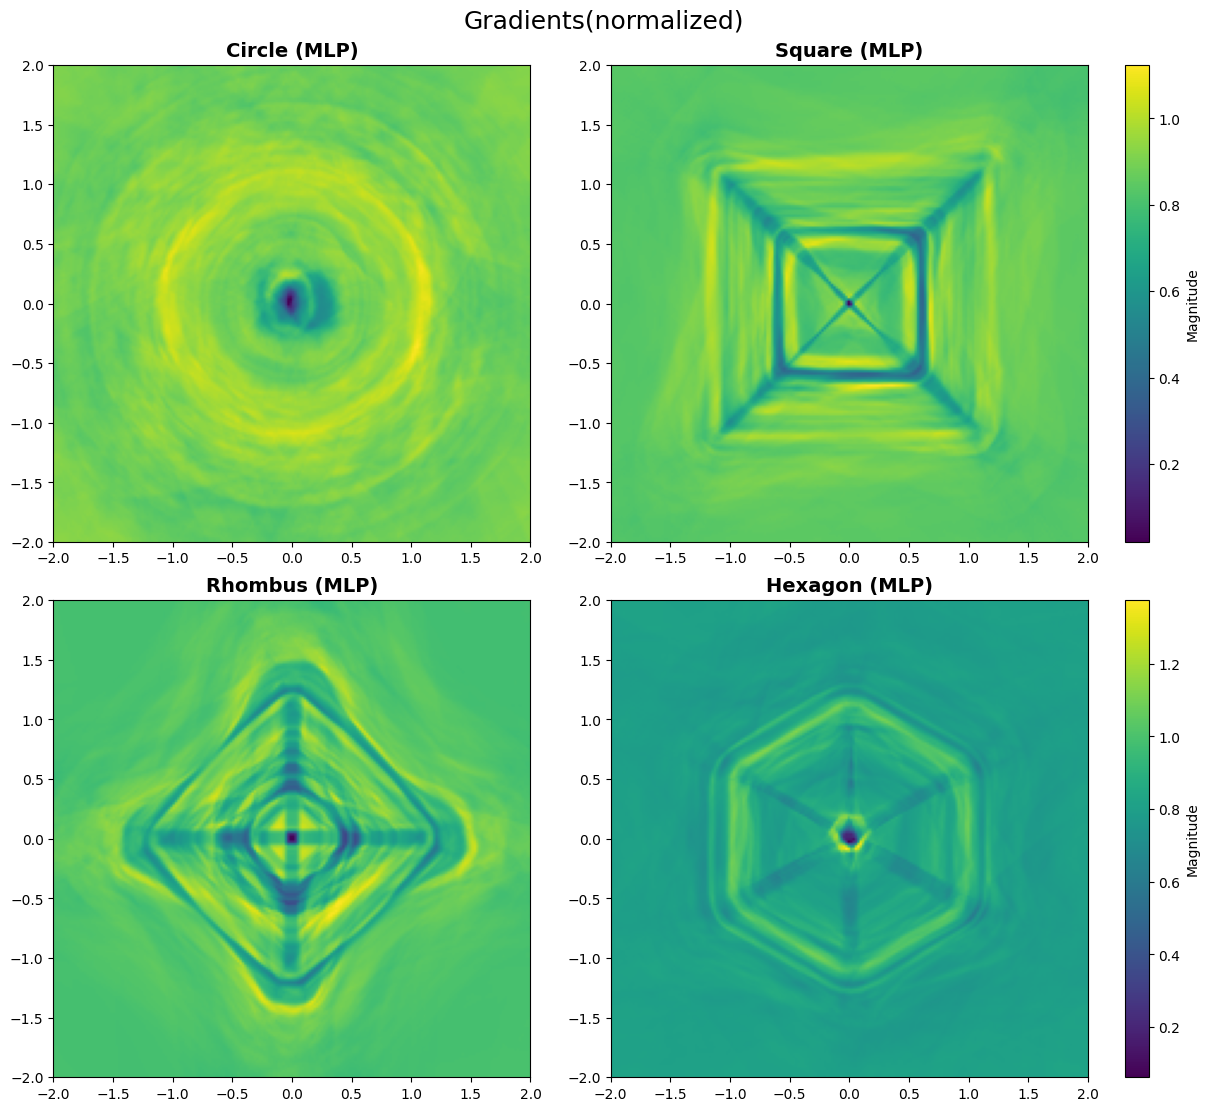

In [90]:
# --- Setup Grid for Inference ---
grid_res = 200
gridx = torch.linspace(-2, 2, grid_res)
gridy = torch.linspace(-2, 2, grid_res)
X_mesh, Y_mesh = torch.meshgrid(gridx, gridy, indexing='ij')
input_pts = torch.stack([X_mesh.flatten(), Y_mesh.flatten()], dim=1).to(device)

# Map your models to their titles
# Assuming mlp_rhombus and others are already trained models
models = [
    ("Circle (MLP)", mlp_circle),
    ("Square (MLP)", mlp_square),
    ("Rhombus (MLP)", mlp_rhombus),
    ("Hexagon (MLP)", mlp_hexagon)
]

# --- Plotting the 2x2 Layout ---
fig, axes = plt.subplots(2, 2, figsize=(12, 11), constrained_layout=True)
axes = axes.flatten()

for i, (name, model) in enumerate(models):
    ax = axes[i]
    model.eval()
    
    with torch.no_grad():
        # Inference
        Z_flat = model(input_pts)
        Z = Z_flat.reshape(grid_res, grid_res).cpu().numpy()
        
    # Convert mesh to numpy for plotting
    xn = X_mesh.cpu().numpy()
    yn = Y_mesh.cpu().numpy()
    
    # Distance Field Contour
    max_abs = np.max(np.abs(Z))
    cp = ax.contourf(xn, yn, Z, levels=100, cmap='RdBu', vmin=-max_abs, vmax=max_abs)
    
    # The Zero-level set (The learned boundary)
    ax.contour(xn, yn, Z, levels=[0], colors='white', linewidths=2)
    
    # Formatting
    ax.set_title(name, fontsize=14, fontweight='bold')
    ax.set_aspect('equal')
    ax.set_xlim(-2, 2)
    ax.set_ylim(-2, 2)
    
    if i % 2 == 1:
        fig.colorbar(cp, ax=ax, label='Predicted Distance')

plt.suptitle("Neural SDF Approximations (MLP)", fontsize=18)
plt.show()

# --- Gradient Magnitude of the MLP ---
fig, axes = plt.subplots(2, 2, figsize=(12, 11), constrained_layout=True)
axes = axes.flatten()

spacing = (gridx[1] - gridx[0]).item()

for i, (name, model) in enumerate(models):
    ax = axes[i]
    
    # Re-calculating Z for each model
    with torch.no_grad():
        Z = model(input_pts).reshape(grid_res, grid_res).cpu().numpy()
    
    # Numerical gradient of the MLP output
    gy, gx = np.gradient(Z, spacing)
    magnitude = np.sqrt(gx**2 + gy**2)
    
    im = ax.imshow(magnitude, extent=[-2, 2, -2, 2], origin='lower', cmap='viridis')
    ax.set_title(f"{name}", fontsize=14, fontweight='bold')
    ax.set_aspect('equal')
    
    if i % 2 == 1:
        fig.colorbar(im, ax=ax, label='Magnitude')

plt.suptitle("Gradients(normalized)", fontsize=18)
plt.show()


## Adding eikonal loss

In [71]:
import torch
import torch.nn as nn


"""
This network class is from https://github.com/mintpancake/2d-sdf-net and was slightly modified"""


# The structure proposed in DeepSDF paper
class SDFNet(nn.Module):
    def __init__(self, dropout_prob=0.2, inDim=2):
        super(SDFNet, self).__init__()
        self.fc_stack_1 = nn.Sequential(
            nn.utils.weight_norm(nn.Linear(inDim, 512)),
            nn.ReLU(),
            nn.Dropout(p=dropout_prob),
            nn.utils.weight_norm(nn.Linear(512, 512)),
            nn.ReLU(),
            nn.Dropout(p=dropout_prob),
            nn.utils.weight_norm(nn.Linear(512, 512)),
            nn.ReLU(),
            nn.Dropout(p=dropout_prob),
            nn.utils.weight_norm(nn.Linear(512, 512 - inDim)),  # 510 = 512 - 2
            nn.ReLU(),
            nn.Dropout(p=dropout_prob)
        )
        self.fc_stack_2 = nn.Sequential(
            nn.utils.weight_norm(nn.Linear(512, 512)),
            nn.ReLU(),
            nn.Dropout(p=dropout_prob),
            nn.utils.weight_norm(nn.Linear(512, 512)),
            nn.ReLU(),
            nn.Dropout(p=dropout_prob),
            nn.utils.weight_norm(nn.Linear(512, 512)),
            nn.ReLU(),
            nn.Dropout(p=dropout_prob),
            nn.utils.weight_norm(nn.Linear(512, 1))
        )
        self.th = nn.Tanh()

    def forward(self, x):
        skip_out = self.fc_stack_1(x)
        skip_in = torch.cat([skip_out, x], 1)
        return self.fc_stack_2(skip_in)

    def gradient(self, points: torch.Tensor) -> torch.Tensor:
        """
        SDF gradient
        :param points: points tensor, size (n, 2)
        :return: gradient tensor, size (n, 2)
        """
        points.requires_grad_(True)
        y = self.forward(points)
        d_output = torch.ones_like(y, requires_grad=False, device=y.device)
        grad = torch.autograd.grad(outputs=y, inputs=points, grad_outputs=d_output, create_graph=True, retain_graph=True, only_inputs=True)[0]
        return grad.unsqueeze(1)

In [ ]:
def train_sdfeik(model, sdf_func, nb_samples, lr, nb_epochs, loss_type='mse'):
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss() if loss_type == 'mse' else nn.L1Loss()

    for epoch in range(nb_epochs):

        x = (torch.rand(nb_samples, 2, device=device) * 4) - 2
        target = torch.from_numpy(sdf_func(x[:,0].cpu().numpy(), x[:,1].cpu().numpy(), 1.0)).float().to(device)
        optimizer.zero_grad()
        output = model(x).squeeze()
    
        loss_dist = criterion(output, target)
        norm_grad = torch.norm(model.gradient(x), dim=-1).squeeze()
        loss_eikonal = torch.mean((norm_grad - 1.0)**2)
        total_loss = loss_dist + 0.1 * loss_eikonal
        total_loss.backward()
        optimizer.step()

        if epoch % 100 == 0:
            print(f"Epoch {epoch} | Total: {total_loss.item():.5f} | MSE: {loss_dist.item():.5f} | Eik: {loss_eikonal.item():.5f}")
            
    return model

In [75]:
mlp_circle = train_sdfeik(SDFNet(), circle, 10000, 0.001, 5000, 'mse')
mlp_square = train_sdfeik(SDFNet(), square, 10000, 0.001, 5000, 'mse')
mlp_hexagon = train_sdfeik(SDFNet(), sdHexagon, 10000, 0.001, 5000, 'mse')
mlp_rhombus = train_sdfeik(SDFNet(), sdRhombus, 10000, 0.001, 5000, 'mse')

/home/atarrade/dev/anaconda3/envs/mlp-test/lib/python3.11/site-packages/torch/nn/utils/weight_norm.py:144: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)


Epoch 0 | Total: 0.74989 | MSE: 0.65059 | Eik: 0.99296
Epoch 100 | Total: 0.02265 | MSE: 0.01741 | Eik: 0.05235
Epoch 200 | Total: 0.00923 | MSE: 0.00748 | Eik: 0.01746
Epoch 300 | Total: 0.00640 | MSE: 0.00518 | Eik: 0.01224
Epoch 400 | Total: 0.00534 | MSE: 0.00437 | Eik: 0.00967
Epoch 500 | Total: 0.00488 | MSE: 0.00398 | Eik: 0.00904
Epoch 600 | Total: 0.00438 | MSE: 0.00355 | Eik: 0.00833
Epoch 700 | Total: 0.00412 | MSE: 0.00332 | Eik: 0.00801
Epoch 800 | Total: 0.00381 | MSE: 0.00304 | Eik: 0.00767
Epoch 900 | Total: 0.00394 | MSE: 0.00316 | Eik: 0.00776
Epoch 1000 | Total: 0.00337 | MSE: 0.00270 | Eik: 0.00674
Epoch 1100 | Total: 0.00343 | MSE: 0.00274 | Eik: 0.00692
Epoch 1200 | Total: 0.00315 | MSE: 0.00250 | Eik: 0.00650
Epoch 1300 | Total: 0.00302 | MSE: 0.00238 | Eik: 0.00646
Epoch 1400 | Total: 0.00291 | MSE: 0.00228 | Eik: 0.00630
Epoch 1500 | Total: 0.00274 | MSE: 0.00218 | Eik: 0.00567
Epoch 1600 | Total: 0.00265 | MSE: 0.00209 | Eik: 0.00567
Epoch 1700 | Total: 0.0024

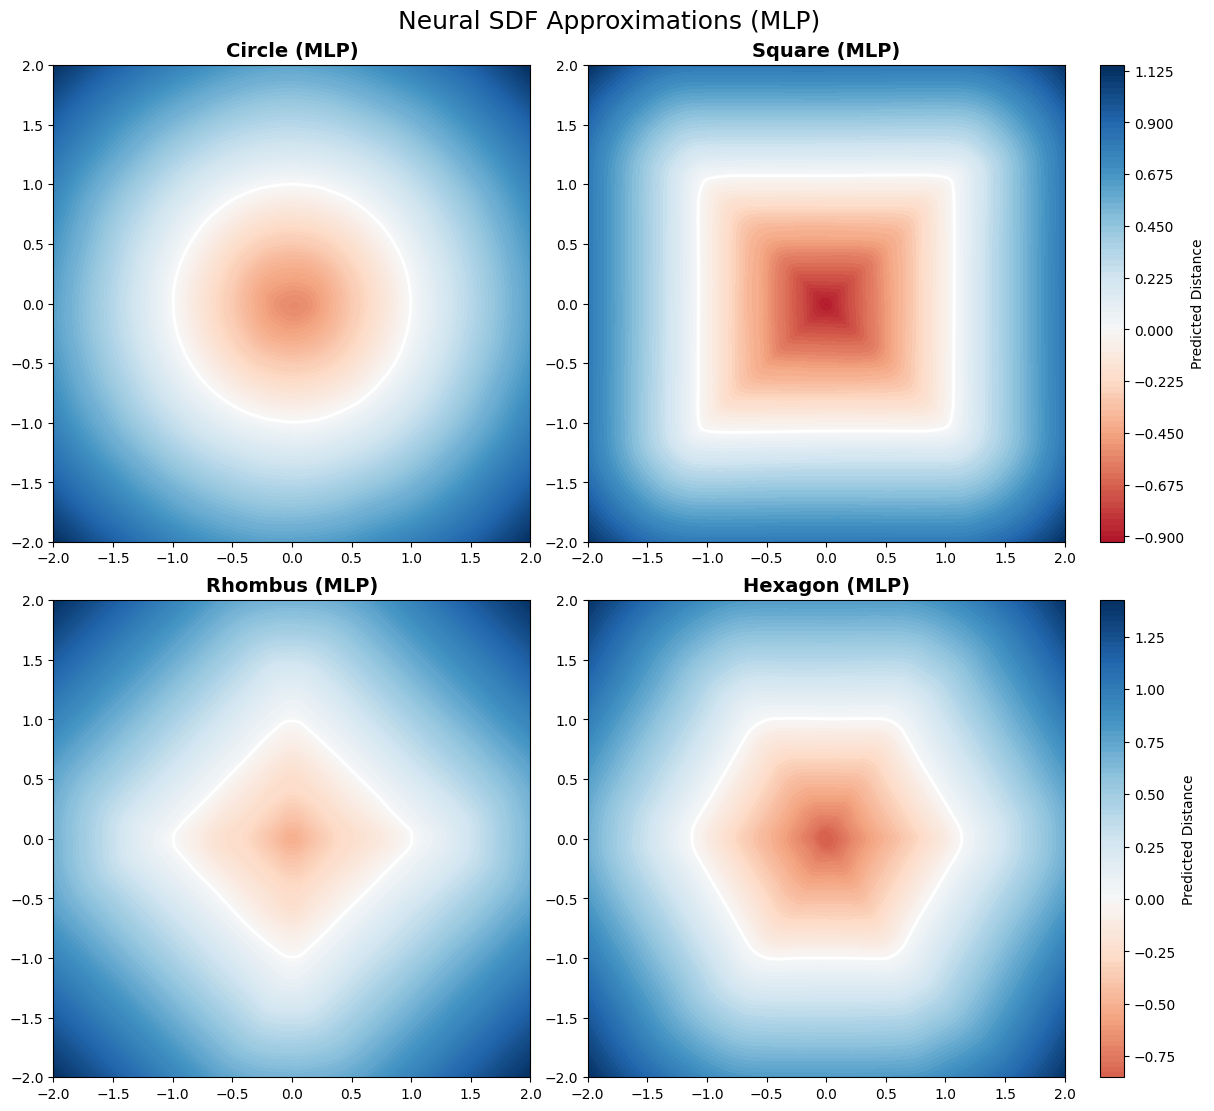

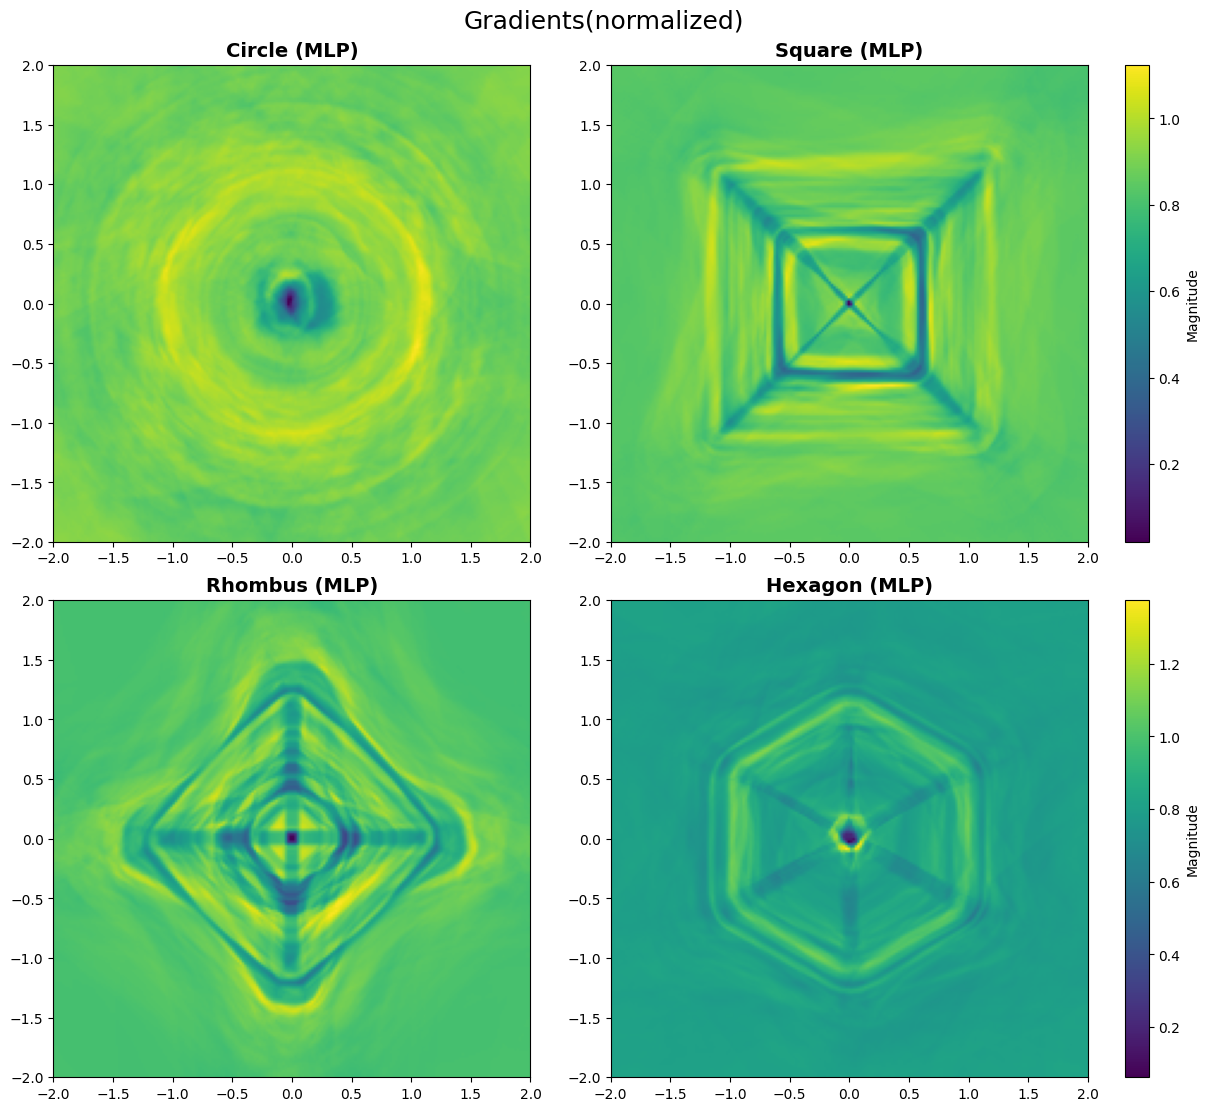

In [91]:
# --- Setup Grid for Inference ---
grid_res = 200
gridx = torch.linspace(-2, 2, grid_res)
gridy = torch.linspace(-2, 2, grid_res)
X_mesh, Y_mesh = torch.meshgrid(gridx, gridy, indexing='ij')
input_pts = torch.stack([X_mesh.flatten(), Y_mesh.flatten()], dim=1).to(device)

# Map your models to their titles
# Assuming mlp_rhombus and others are already trained models
models = [
    ("Circle (MLP)", mlp_circle),
    ("Square (MLP)", mlp_square),
    ("Rhombus (MLP)", mlp_rhombus),
    ("Hexagon (MLP)", mlp_hexagon)
]

# --- Plotting the 2x2 Layout ---
fig, axes = plt.subplots(2, 2, figsize=(12, 11), constrained_layout=True)
axes = axes.flatten()

for i, (name, model) in enumerate(models):
    ax = axes[i]
    model.eval()
    
    with torch.no_grad():
        # Inference
        Z_flat = model(input_pts)
        Z = Z_flat.reshape(grid_res, grid_res).cpu().numpy()
        
    # Convert mesh to numpy for plotting
    xn = X_mesh.cpu().numpy()
    yn = Y_mesh.cpu().numpy()
    
    # Distance Field Contour
    max_abs = np.max(np.abs(Z))
    cp = ax.contourf(xn, yn, Z, levels=100, cmap='RdBu', vmin=-max_abs, vmax=max_abs)
    
    # The Zero-level set (The learned boundary)
    ax.contour(xn, yn, Z, levels=[0], colors='white', linewidths=2)
    
    # Formatting
    ax.set_title(name, fontsize=14, fontweight='bold')
    ax.set_aspect('equal')
    ax.set_xlim(-2, 2)
    ax.set_ylim(-2, 2)
    
    if i % 2 == 1:
        fig.colorbar(cp, ax=ax, label='Predicted Distance')

plt.suptitle("Neural SDF Approximations (MLP)", fontsize=18)
plt.show()

# --- Gradient Magnitude of the MLP ---
fig, axes = plt.subplots(2, 2, figsize=(12, 11), constrained_layout=True)
axes = axes.flatten()

spacing = (gridx[1] - gridx[0]).item()

for i, (name, model) in enumerate(models):
    ax = axes[i]
    
    # Re-calculating Z for each model
    with torch.no_grad():
        Z = model(input_pts).reshape(grid_res, grid_res).cpu().numpy()
    
    # Numerical gradient of the MLP output
    gy, gx = np.gradient(Z, spacing)
    magnitude = np.sqrt(gx**2 + gy**2)
    
    im = ax.imshow(magnitude, extent=[-2, 2, -2, 2], origin='lower', cmap='viridis')
    ax.set_title(f"{name}", fontsize=14, fontweight='bold')
    ax.set_aspect('equal')
    
    if i % 2 == 1:
        fig.colorbar(im, ax=ax, label='Magnitude')

plt.suptitle("Gradients(normalized)", fontsize=18)
plt.show()

## Positionnal encoding

In [72]:

def positional_encoding(x, num_frequencies):
    encoding = []
    for i in range(x.shape[-1]):
        xi = x[..., i:i+1] 
        encoding.append(xi) 
        frequencies = 2 ** torch.arange(num_frequencies, dtype=x.dtype, device=x.device)
        for freq in frequencies:
            encoding.append(torch.sin(freq * xi))
            encoding.append(torch.cos(freq * xi))
    return torch.cat(encoding, dim=-1)  


class SharpMLP(nn.Module):
    def __init__(self,num_frequencies=6):
        super().__init__()
        self.num_frequencies = num_frequencies
        input_size = 2 + 4 * num_frequencies
        self.layers = nn.Sequential(
            nn.Linear(input_size,256),
            nn.ReLU(),
            nn.Linear(256, 256),
            nn.ReLU(),
            nn.Linear(256, 256),
            nn.ReLU(),
            nn.Linear(256, 1)
        )

    def forward(self,x):
        x_enc = positional_encoding(x, self.num_frequencies)
        return self.layers(x_enc)

In [73]:
mlp_sharp = train_sdf(SharpMLP(12), square, 100000, 0.001, 20000, 'l1')

/tmp/ipykernel_537806/3683762438.py:6: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  dx = np.abs(x) - r
/tmp/ipykernel_537806/3683762438.py:7: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  dy = np.abs(y) - r
/tmp/ipykernel_537806/3683762438.py:10: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  external_dist = np.sqrt(np.maximum(dx, 0.0)**2 + np.maximum(dy, 0.0)**2)
/tmp/ipykernel_537806/3683762438.py:12: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  internal_dist = np.minimum(np.maximum(dx, dy), 0.0)


Epoch 0, Loss: 4.399785041809082
Epoch 100, Loss: 0.08808322995901108
Epoch 200, Loss: 0.05565013363957405
Epoch 300, Loss: 0.04169861227273941
Epoch 400, Loss: 0.03654039278626442
Epoch 500, Loss: 0.03400780260562897
Epoch 600, Loss: 0.0329536497592926
Epoch 700, Loss: 0.030965782701969147
Epoch 800, Loss: 0.030614390969276428
Epoch 900, Loss: 0.029568102210760117
Epoch 1000, Loss: 0.029104407876729965
Epoch 1100, Loss: 0.028147229924798012
Epoch 1200, Loss: 0.027757151052355766
Epoch 1300, Loss: 0.02724297344684601
Epoch 1400, Loss: 0.02668122947216034
Epoch 1500, Loss: 0.0263030007481575
Epoch 1600, Loss: 0.025967802852392197
Epoch 1700, Loss: 0.025683607906103134
Epoch 1800, Loss: 0.02551104500889778
Epoch 1900, Loss: 0.02539774589240551
Epoch 2000, Loss: 0.02517532743513584
Epoch 2100, Loss: 0.02449476532638073
Epoch 2200, Loss: 0.02468843013048172
Epoch 2300, Loss: 0.023898085579276085
Epoch 2400, Loss: 0.02400006726384163
Epoch 2500, Loss: 0.02371915429830551
Epoch 2600, Loss: 0

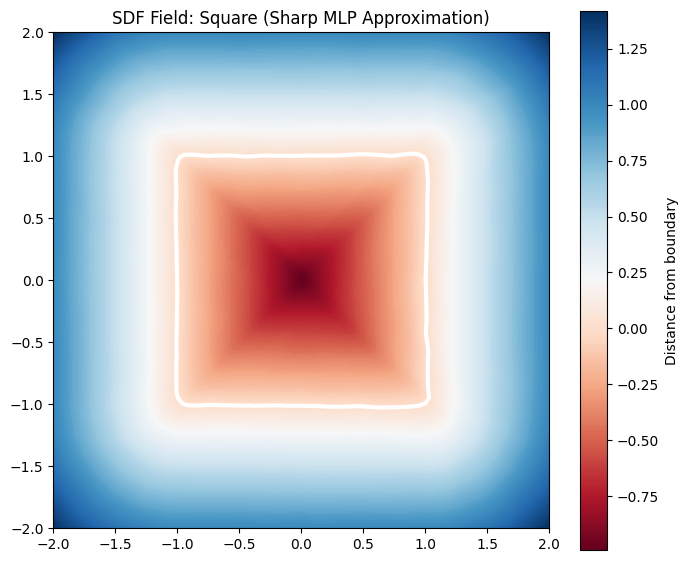

In [74]:
with torch.no_grad():
    gridx = torch.linspace(-2,2,100)
    gridy = torch.linspace(-2,2,100)
    X,Y = torch.meshgrid(gridx,gridy)
    X = X.to(device)
    Y = Y.to(device)
    Z = mlp(torch.stack([X.flatten(), Y.flatten()], dim=1)).squeeze().reshape(X.shape)
    X = X.cpu().numpy()
    Y = Y.cpu().numpy()
    Z = Z.cpu().numpy()

plt.figure(figsize=(8, 7))


cp = plt.contourf(X, Y, Z, levels=250, cmap='RdBu')
plt.colorbar(cp, label='Distance from boundary')


plt.contour(X, Y, Z, levels=[0], colors='white', linewidths=3)

plt.title("SDF Field: Square (Sharp MLP Approximation)")
plt.gca().set_aspect('equal')
plt.show()

## Adding high frequences

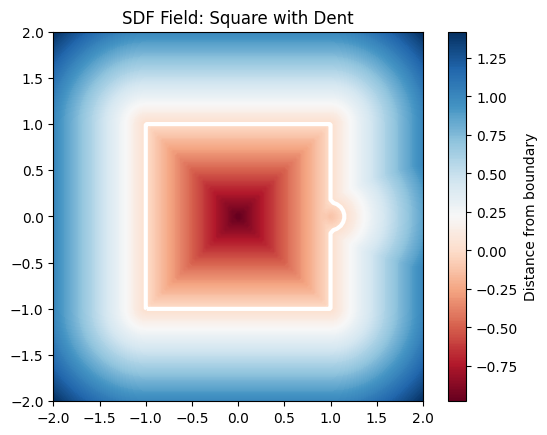

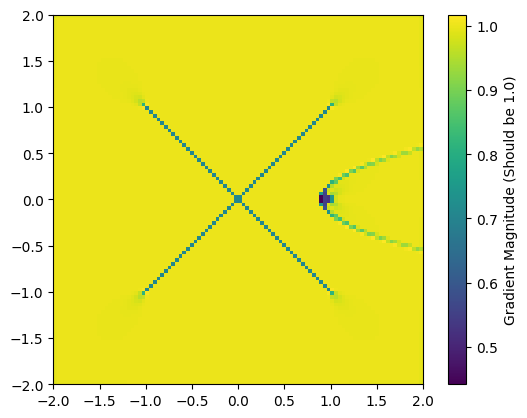

In [29]:
def hf_square(x, y, r=1.0, dent_radius=0.15):
    """
    Mathematically valid SDF: square with circular indentation (dent).
    The dent is modeled as a true circular indentation at (r, 0).
    Distance = min distance to square OR to dent circle (proper SDF union).
    """
    # 1. Compute proper distance to square (box SDF)
    dx = np.abs(x) - r
    dy = np.abs(y) - r
    # Exterior distance (outside box)
    dist_outside_sq = np.sqrt(np.maximum(dx, 0)**2 + np.maximum(dy, 0)**2)
    # Interior distance (inside box)
    dist_inside_sq = np.minimum(np.maximum(dx, dy), 0)
    dist_to_square = dist_outside_sq + dist_inside_sq
    
    # 2. Compute distance to dent (circle at right edge)
    dist_to_dent_center = np.sqrt((x - r)**2 + (y - 0)**2)
    dist_to_dent = dist_to_dent_center - dent_radius
    
    # 3. Union: distance to closest surface
    # The dent is a circular indentation, so we take minimum
    result = np.minimum(dist_to_square, dist_to_dent)
    return result


gridx = np.linspace(-2,2,100)
gridy = np.linspace(-2,2,100)
X,Y = np.meshgrid(gridx,gridy)
Z = hf_square(X,Y,1,0.15)


cp = plt.contourf(X, Y, Z, levels=250, cmap='RdBu')
plt.colorbar(cp, label='Distance from boundary')


plt.contour(X, Y, Z, levels=[0], colors='white', linewidths=3)

plt.title("SDF Field: Square with Dent")
plt.gca().set_aspect('equal')
plt.show()

gy, gx = np.gradient(Z, gridx[1]-gridx[0])
magnitude = np.sqrt(gx**2 + gy**2)
plt.imshow(magnitude, extent=[-2,2,-2,2])
plt.colorbar(label="Gradient Magnitude (Should be 1.0)")

In [22]:
# Train MLP on hf_square
mlp_hf = train_sdf(MLP(), hf_square, 100000, 0.001, 20000, 'mse')

/tmp/ipykernel_537806/127625525.py:8: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  dx = np.abs(x) - r
/tmp/ipykernel_537806/127625525.py:9: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  dy = np.abs(y) - r
/tmp/ipykernel_537806/127625525.py:11: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  dist_outside_sq = np.sqrt(np.maximum(dx, 0)**2 + np.maximum(dy, 0)**2)
/tmp/ipykernel_537806/127625525.py:13: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  dist_inside_sq = np.minimum(np.maximum(dx, dy), 0)
/tmp/ipykernel_537806/127625525.py:17: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionall

Epoch 0, Loss: 29.367393493652344
Epoch 100, Loss: 0.09707940369844437
Epoch 200, Loss: 0.005558868870139122
Epoch 300, Loss: 0.002767687663435936
Epoch 400, Loss: 0.0016589509323239326
Epoch 500, Loss: 0.0010987322311848402
Epoch 600, Loss: 0.0007701462600380182
Epoch 700, Loss: 0.0005684210918843746
Epoch 800, Loss: 0.0004581866378430277
Epoch 900, Loss: 0.0003853925154544413
Epoch 1000, Loss: 0.00036264793016016483
Epoch 1100, Loss: 0.00029312624246813357
Epoch 1200, Loss: 0.0002616510901134461
Epoch 1300, Loss: 0.0002531080972403288
Epoch 1400, Loss: 0.00021286703122314066
Epoch 1500, Loss: 0.0001939402864081785
Epoch 1600, Loss: 0.0001766267669154331
Epoch 1700, Loss: 0.00016375479754060507
Epoch 1800, Loss: 0.0001499222416896373
Epoch 1900, Loss: 0.00014115803060121834
Epoch 2000, Loss: 0.0001297371491091326
Epoch 2100, Loss: 0.0001435104786651209
Epoch 2200, Loss: 0.00011422513489378616
Epoch 2300, Loss: 0.00010971227311529219
Epoch 2400, Loss: 0.00010236269736196846
Epoch 2500,

KeyboardInterrupt: 

In [21]:
# Plot MLP trained on hf_square
with torch.no_grad():
    gridx = torch.linspace(-2,2,100)
    gridy = torch.linspace(-2,2,100)
    X,Y = torch.meshgrid(gridx,gridy)
    X = X.to(device)
    Y = Y.to(device)
    Z = mlp_hf(torch.stack([X.flatten(), Y.flatten()], dim=1)).reshape(X.shape)

    X = X.cpu().numpy()
    Y = Y.cpu().numpy()
    Z = Z.cpu().numpy()

plt.figure(figsize=(8, 7))
cp = plt.contourf(X, Y, Z, levels=250, cmap='RdBu')
plt.colorbar(cp, label='Distance from boundary')


plt.contour(X, Y, Z, levels=[0], colors='white', linewidths=3)

plt.title("SDF Field: Square with Dent")
plt.gca().set_aspect('equal')
plt.show()

NameError: name 'mlp_hf' is not defined

In [38]:
# Train SharpMLP on hf_square
mlp_sharp_hf = train_sdf(SharpMLP(12), hf_square, 100000, 0.001, 20000, 'l1')

/tmp/ipykernel_30072/2610889985.py:8: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  dx = np.abs(x) - r
/tmp/ipykernel_30072/2610889985.py:9: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  dy = np.abs(y) - r
/tmp/ipykernel_30072/2610889985.py:11: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  dist_outside_sq = np.sqrt(np.maximum(dx, 0)**2 + np.maximum(dy, 0)**2)
/tmp/ipykernel_30072/2610889985.py:13: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  dist_inside_sq = np.minimum(np.maximum(dx, dy), 0)
/tmp/ipykernel_30072/2610889985.py:17: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionall

Epoch 0, Loss: 4.306525707244873
Epoch 100, Loss: 0.08245308697223663
Epoch 200, Loss: 0.050368860363960266
Epoch 300, Loss: 0.04070728272199631
Epoch 400, Loss: 0.03635109215974808
Epoch 500, Loss: 0.034918662160634995
Epoch 600, Loss: 0.03388218581676483
Epoch 700, Loss: 0.03173355758190155
Epoch 800, Loss: 0.030218880623579025
Epoch 900, Loss: 0.02931876666843891
Epoch 1000, Loss: 0.02893574722111225
Epoch 1100, Loss: 0.028188763186335564
Epoch 1200, Loss: 0.027690760791301727
Epoch 1300, Loss: 0.02707001380622387
Epoch 1400, Loss: 0.026753803715109825
Epoch 1500, Loss: 0.0262357909232378
Epoch 1600, Loss: 0.025327345356345177
Epoch 1700, Loss: 0.02509051188826561
Epoch 1800, Loss: 0.025197353214025497
Epoch 1900, Loss: 0.02507859468460083
Epoch 2000, Loss: 0.024723591282963753
Epoch 2100, Loss: 0.024549750611186028
Epoch 2200, Loss: 0.02401275560259819
Epoch 2300, Loss: 0.02364596538245678
Epoch 2400, Loss: 0.02359117567539215
Epoch 2500, Loss: 0.023453200235962868
Epoch 2600, Loss

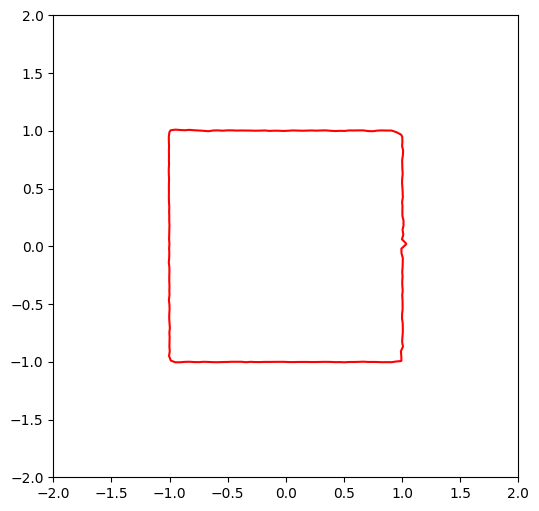

In [32]:
# Plot SharpMLP trained on hf_square
with torch.no_grad():
    gridx = torch.linspace(-2,2,100)
    gridy = torch.linspace(-2,2,100)
    X,Y = torch.meshgrid(gridx,gridy)
    X = X.to(device)
    Y = Y.to(device)
    Z = mlp_sharp_hf(torch.stack([X.flatten(), Y.flatten()], dim=1)).squeeze().reshape(X.shape)
    X = X.cpu().numpy()
    Y = Y.cpu().numpy()
    Z = Z.cpu().numpy()

plt.figure(figsize=(6,6))
plt.contour(X,Y,Z,levels=[0], colors='red')
plt.show()